In [1]:
from typing import Dict, Any
import torch
from torch import Generator, logspace
from tqdm import tqdm

from occhio.autoencoder import *
from occhio.distributions import *
from occhio.toy_model import ToyModel
from occhio.model_grid import ModelGrid, Axis
from occhio.visualization.phase_change import plot_phase_change

In [2]:
N_FEATURES = 5
N_HIDDEN = 2
EXPERIMENT_SIZE = 20

In [3]:
def create_model(
    params: Dict[str, Any] = {}, default_model: ToyModel | None = None, *args, **kwargs
) -> ToyModel:
    density = params["Density"]
    relative_importance = params["Importance"]
    # random_seed = params["Random Seeds"]

    generator = Generator(device="mps").manual_seed(42)

    model = ToyModel(
        distribution=SparseUniform(
            N_FEATURES, p_active=density, device="mps", generator=generator
        ),
        ae=TiedLinearRelu(
            N_FEATURES,
            N_HIDDEN,
            generator=generator,
            device="mps",
        ),
        importances=relative_importance ** torch.arange(N_FEATURES),
        device="mps",
    )
    return model

In [4]:
densities = logspace(0, -2, EXPERIMENT_SIZE)
importances = logspace(-1, 1, EXPERIMENT_SIZE)
# random_seeds = torch.arange(10, 20, dtype=torch.float32)

model_grid = ModelGrid(
    create_model,
    axes=[
        Axis(label="Density", values=densities),
        Axis(label="Importance", values=importances),
        # Axis(label="Random Seeds", values=random_seeds),
    ],
)

In [23]:
len(model_grid.models)

400

In [24]:
model_grid.fit(n_epochs=4000)

In [5]:
model_grid_2 = ModelGrid(
    create_model,
    axes=[
        Axis(label="Density", values=densities),
        Axis(label="Importance", values=importances),
        # Axis(label="Random Seeds", values=random_seeds),
    ],
)

In [ ]:
for model in model_grid_2.models:
    model.fit(n_epochs=4000)

In [7]:
model_grid.models  # trained

[ToyModel(SparseUniform(5, cpu)),
 ToyModel(SparseUniform(5, cpu)),
 ToyModel(SparseUniform(5, cpu)),
 ToyModel(SparseUniform(5, cpu)),
 ToyModel(SparseUniform(5, cpu)),
 ToyModel(SparseUniform(5, cpu)),
 ToyModel(SparseUniform(5, cpu)),
 ToyModel(SparseUniform(5, cpu)),
 ToyModel(SparseUniform(5, cpu)),
 ToyModel(SparseUniform(5, cpu)),
 ToyModel(SparseUniform(5, cpu)),
 ToyModel(SparseUniform(5, cpu)),
 ToyModel(SparseUniform(5, cpu)),
 ToyModel(SparseUniform(5, cpu)),
 ToyModel(SparseUniform(5, cpu)),
 ToyModel(SparseUniform(5, cpu)),
 ToyModel(SparseUniform(5, cpu)),
 ToyModel(SparseUniform(5, cpu)),
 ToyModel(SparseUniform(5, cpu)),
 ToyModel(SparseUniform(5, cpu)),
 ToyModel(SparseUniform(5, cpu)),
 ToyModel(SparseUniform(5, cpu)),
 ToyModel(SparseUniform(5, cpu)),
 ToyModel(SparseUniform(5, cpu)),
 ToyModel(SparseUniform(5, cpu)),
 ToyModel(SparseUniform(5, cpu)),
 ToyModel(SparseUniform(5, cpu)),
 ToyModel(SparseUniform(5, cpu)),
 ToyModel(SparseUniform(5, cpu)),
 ToyModel(Spar

In [8]:
model_grid.models[0]

ToyModel(SparseUniform(5, cpu))

In [9]:
from occhio.visualization.phase_change import plot_phase_change

fig = plot_phase_change(model_grid)

ValueError: all input arrays must have the same shape

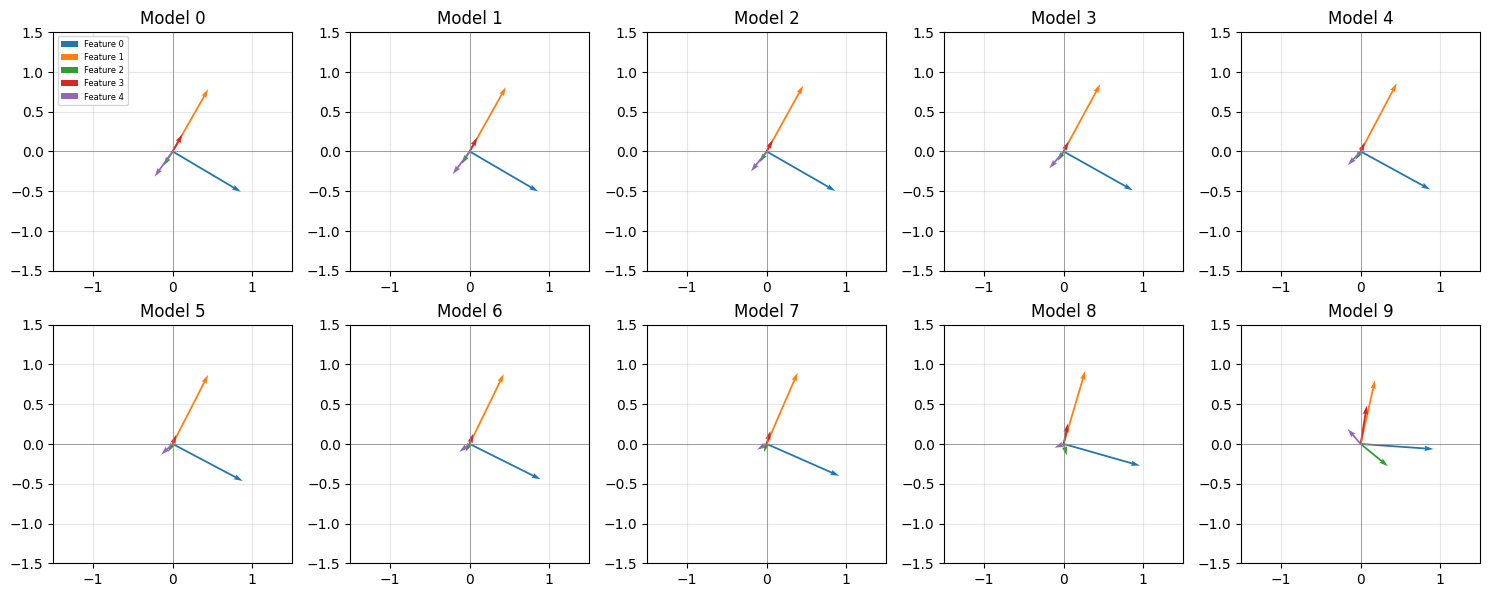

In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i, model in enumerate(model_grid.models[:10]):
    ax = axes[i]
    W = model.W.detach().cpu().numpy()  # Shape: (n_hidden=2, n_features=5)

    # Plot each column of W as a vector from origin
    for j in range(W.shape[1]):
        ax.quiver(
            0,
            0,
            W[0, j],
            W[1, j],
            angles="xy",
            scale_units="xy",
            scale=1,
            label=f"Feature {j}",
            color=plt.cm.tab10(j),
        )

    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)
    ax.set_aspect("equal")
    ax.axhline(0, color="gray", linewidth=0.5)
    ax.axvline(0, color="gray", linewidth=0.5)
    ax.set_title(f"Model {i}")
    ax.grid(True, alpha=0.3)

axes[0].legend(loc="upper left", fontsize=6)
plt.tight_layout()
plt.show()